# Messages per Newsgroup

Visualization of message counts per newsgroup, for full IA data and IA filtered to the NB date span.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from usenet_no.notebook_utils import venn2_fmt

In [13]:
def load_group_counts(path):
    df = pd.read_csv(path)
    df = df[df.newsgroup != "Total"]
    df["newsgroup"] = df["newsgroup"].str.replace(".mbox", "", regex=False)
    return df.sort_values("message_count", ascending=False)


ia_full = load_group_counts("../data/messages_per_group_ia.csv")
ia_filtered = load_group_counts("../data/messages_per_group_ia_date_filtered.csv")
df_nb = load_group_counts("../data/messages_per_group_nb.csv")
ia_full.head(10)

,newsgroup,message_count
322,no.alt.frustrasjoner,273271
16,no.sport.fotball,180575
46,no.teknologi.bil,178192
301,no.alt.motorsykler,177967
31,no.general,168755
157,no.samfunn.religion,168287
224,no.samfunn.politikk.diverse,166469
220,no.it.os.mac.diverse,166425
318,no.it.os.unix.linux.diverse,121626
277,no.alt.diskusjoner,119961


In [14]:
for label, df_ia in [("Full IA", ia_full), ("IA date-filtered", ia_filtered)]:
    shared = set(df_ia["newsgroup"]) & set(df_nb["newsgroup"])
    print(
        f"{label} — groups: {len(df_ia)}, total messages: {df_ia['message_count'].sum():,}"
    )
    print(f"  Groups in both: {len(shared)}")
    print(f"  IA only:        {len(set(df_ia['newsgroup']) - shared)}")
    print(f"  NB only:       {len(set(df_nb['newsgroup']) - shared)}")
    print()
print(f"NB — groups: {len(df_nb)}, total messages: {df_nb['message_count'].sum():,}")

Full IA — groups: 331, total messages: 5,985,245
  Groups in both: 132
  IA only:        199
  NB only:       23

IA date-filtered — groups: 280, total messages: 575,768
  Groups in both: 132
  IA only:        148
  NB only:       23

NB — groups: 155, total messages: 613,626


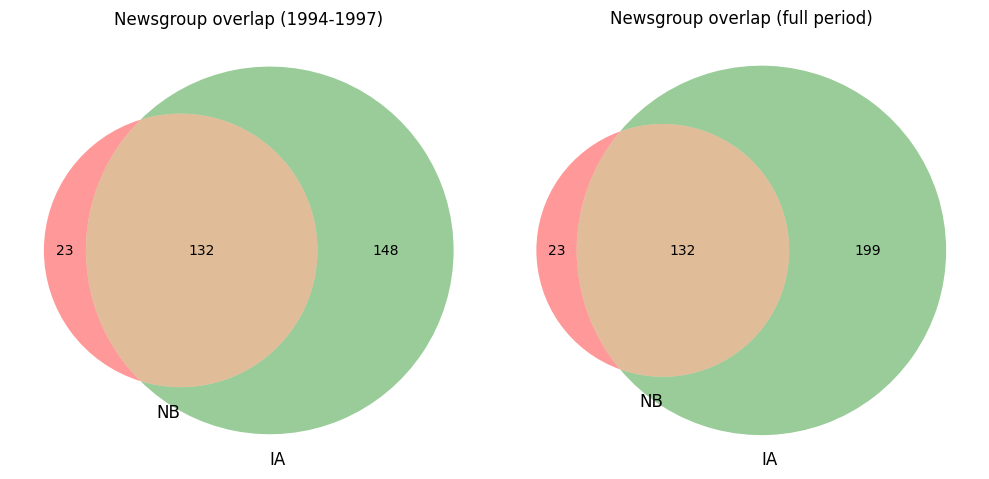

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (label, df_ia) in zip(
    axes, [("1994-1997", ia_filtered), ("full period", ia_full)]
):
    venn2_fmt(
        [set(df_nb["newsgroup"]), set(df_ia["newsgroup"])],
        set_labels=("NB", "IA"),
        ax=ax,
        show_pct=False,
    )
    ax.set_title(f"Newsgroup overlap ({label})")
plt.tight_layout()
plt.show()

# Top 20 newsgroups

## Compare the most frequent newsgroups from the two sources

In [16]:
for label, df_ia in [("Full IA", ia_full), ("IA date-filtered", ia_filtered)]:
    merged = df_ia.merge(df_nb, on="newsgroup", suffixes=("_ia", "_nb"))
    merged["pct_ia"] = merged["message_count_ia"] / df_ia["message_count"].sum() * 100
    merged["pct_nb"] = merged["message_count_nb"] / df_nb["message_count"].sum() * 100
    result = (
        merged[["newsgroup", "pct_ia", "pct_nb"]]
        .sort_values("pct_ia", ascending=False)
        .reset_index(drop=True)
    )
    result["pct_ia"] = result["pct_ia"].map("{:.2f}%".format)
    result["pct_nb"] = result["pct_nb"].map("{:.2f}%".format)
    print(f"\n{label}")
    display(result.head(20))


Full IA


,newsgroup,pct_ia,pct_nb
0,no.alt.frustrasjoner,4.57%,4.58%
1,no.sport.fotball,3.02%,0.38%
2,no.alt.motorsykler,2.97%,6.31%
3,no.general,2.82%,12.54%
4,no.alt.diskusjoner,2.00%,1.73%
5,no.alt.gledesutbrudd,1.53%,1.59%
6,no.pc,1.38%,4.20%
7,no.test,1.37%,0.56%
8,no.marked.data,1.30%,3.70%
9,no.prat.politikk,1.00%,0.60%



IA date-filtered


,newsgroup,pct_ia,pct_nb
0,no.general,13.25%,12.54%
1,no.pc,5.43%,4.20%
2,no.marked.data,4.99%,3.70%
3,no.religion,4.15%,3.33%
4,no.musikk,4.00%,4.49%
5,no.test,3.63%,0.56%
6,no.marked,3.44%,4.39%
7,no.www,3.25%,0.56%
8,no.mac,3.09%,3.61%
9,no.amiga,2.97%,0.53%


In [17]:
for label, df_ia in [("Full IA", ia_full), ("IA date-filtered", ia_filtered)]:
    merged = df_ia.merge(df_nb, on="newsgroup", suffixes=("_ia", "_nb"))
    merged["pct_ia"] = merged["message_count_ia"] / df_ia["message_count"].sum() * 100
    merged["pct_nb"] = merged["message_count_nb"] / df_nb["message_count"].sum() * 100
    result = (
        merged[["newsgroup", "pct_ia", "pct_nb"]]
        .sort_values("pct_nb", ascending=False)
        .reset_index(drop=True)
    )
    result["pct_ia"] = result["pct_ia"].map("{:.2f}%".format)
    result["pct_nb"] = result["pct_nb"].map("{:.2f}%".format)
    print(f"\n{label}")
    display(result.head(20))


Full IA


,newsgroup,pct_ia,pct_nb
0,no.general,2.82%,12.54%
1,no.alt.motorsykler,2.97%,6.31%
2,no.alt.frustrasjoner,4.57%,4.58%
3,no.musikk,0.84%,4.49%
4,no.marked,0.80%,4.39%
5,no.pc,1.38%,4.20%
6,no.marked.data,1.30%,3.70%
7,no.mac,0.72%,3.61%
8,no.religion,0.82%,3.33%
9,no.alt.flame,0.53%,3.25%



IA date-filtered


,newsgroup,pct_ia,pct_nb
0,no.general,13.25%,12.54%
1,no.alt.motorsykler,0.00%,6.31%
2,no.alt.frustrasjoner,0.01%,4.58%
3,no.musikk,4.00%,4.49%
4,no.marked,3.44%,4.39%
5,no.pc,5.43%,4.20%
6,no.marked.data,4.99%,3.70%
7,no.mac,3.09%,3.61%
8,no.religion,4.15%,3.33%
9,no.alt.flame,2.81%,3.25%


In [18]:
def plot_top_vs_rest(df, title):
    top_20_sum = df.head(20)["message_count"].sum()
    rest_sum = df.iloc[20:]["message_count"].sum()
    rest_label = f"Rest ({len(df) - 20})"
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.bar(["Top 20", rest_label], [top_20_sum, rest_sum])
    for i, v in enumerate([top_20_sum, rest_sum]):
        ax.text(i, v, f"{v:,}".replace(",", " "), ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Total Messages")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_distribution(df, title):
    bin_size = 5000
    max_count = int(np.ceil(df["message_count"].max() / bin_size) * bin_size)
    bins = np.arange(0, max_count + bin_size, bin_size)
    counts, bin_edges = np.histogram(df["message_count"], bins=bins)
    non_empty = np.where(counts > 0)[0]
    labels = [
        f"{int(bin_edges[i]):,}\u2013{int(bin_edges[i + 1]):,}".replace(",", " ")
        for i in non_empty
    ]
    counts = counts[non_empty]
    gap_width = 0.9
    x_positions = [0.0]
    for i in range(1, len(non_empty)):
        step = 1.0
        if non_empty[i] - non_empty[i - 1] > 1:
            step += gap_width
        x_positions.append(x_positions[-1] + step)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x_positions, counts, width=0.8)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    for x, c in zip(x_positions, counts):
        ax.text(x, c, str(c), ha="center", va="bottom", fontsize=8)
    ax.set_xlabel("Message Count Range")
    ax.set_ylabel("Number of Newsgroups")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

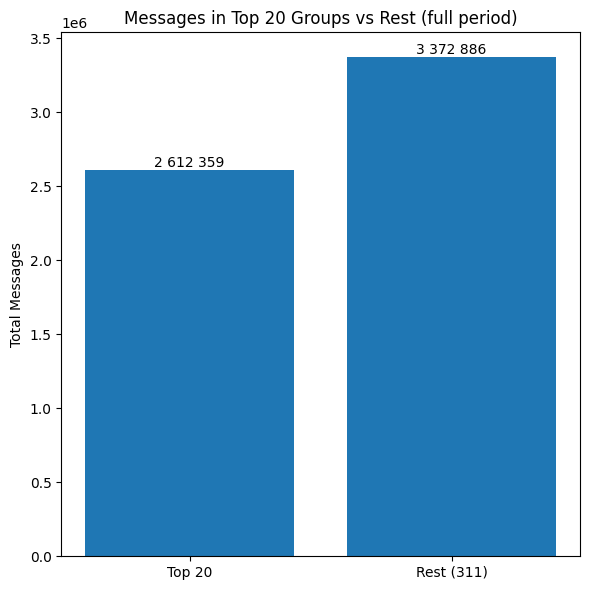

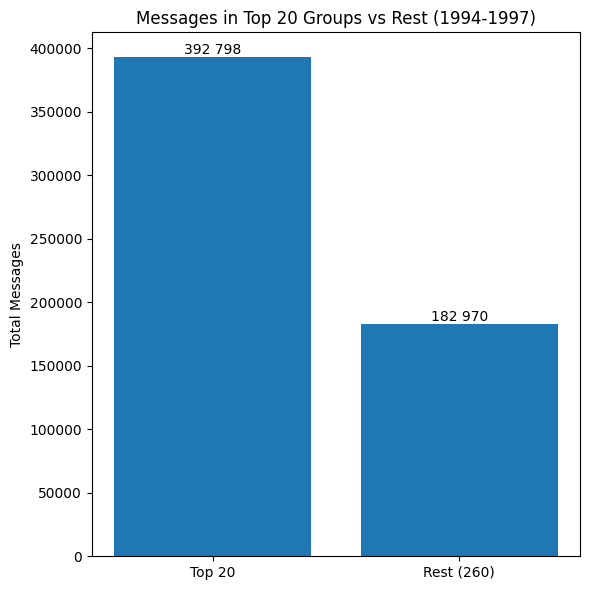

In [19]:
for label, df_ia in [("full period", ia_full), ("1994-1997", ia_filtered)]:
    plot_top_vs_rest(df_ia, f"Messages in Top 20 Groups vs Rest ({label})")

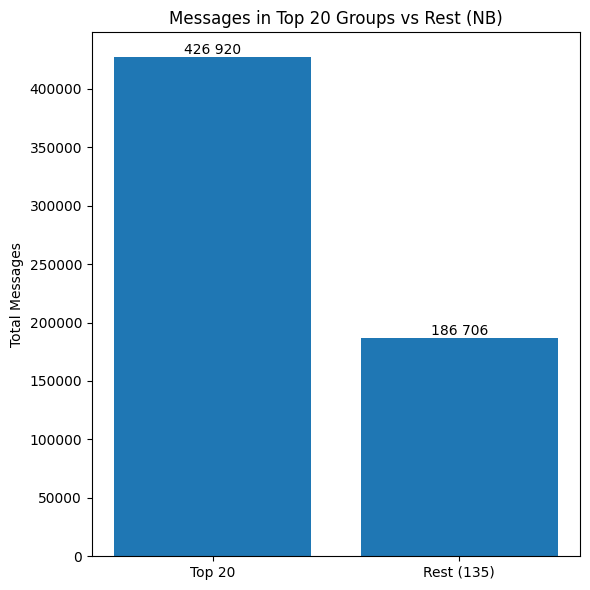

In [20]:
plot_top_vs_rest(df_nb, "Messages in Top 20 Groups vs Rest (NB)")

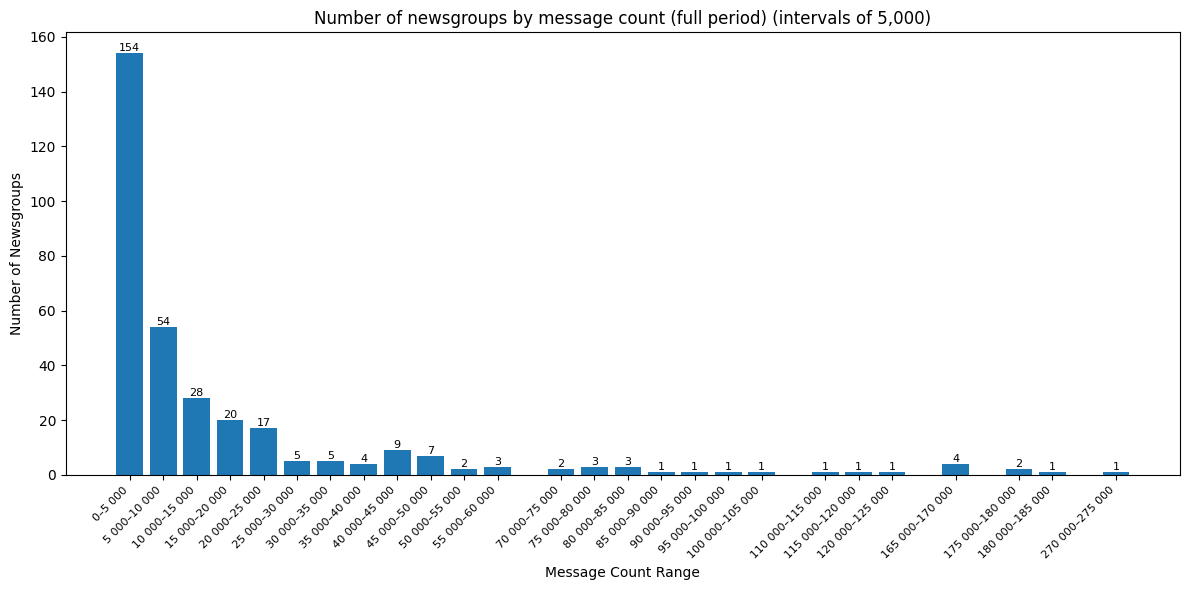

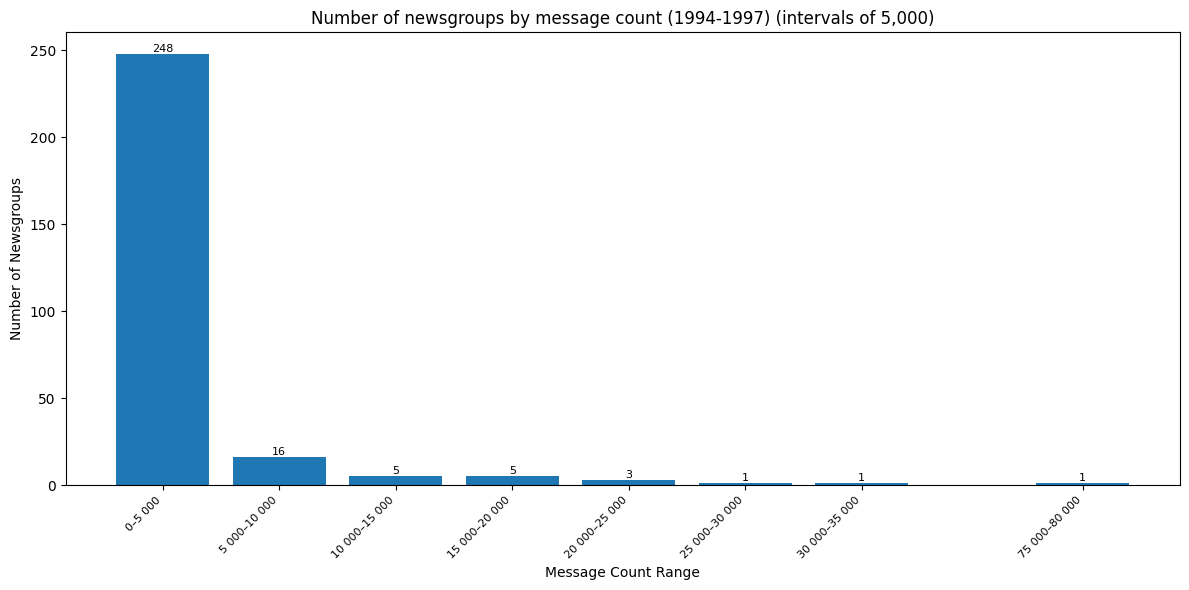

In [21]:
for label, df_ia in [("full period", ia_full), ("1994-1997", ia_filtered)]:
    plot_distribution(
        df_ia,
        f"Number of newsgroups by message count ({label}) (intervals of 5,000)",
    )

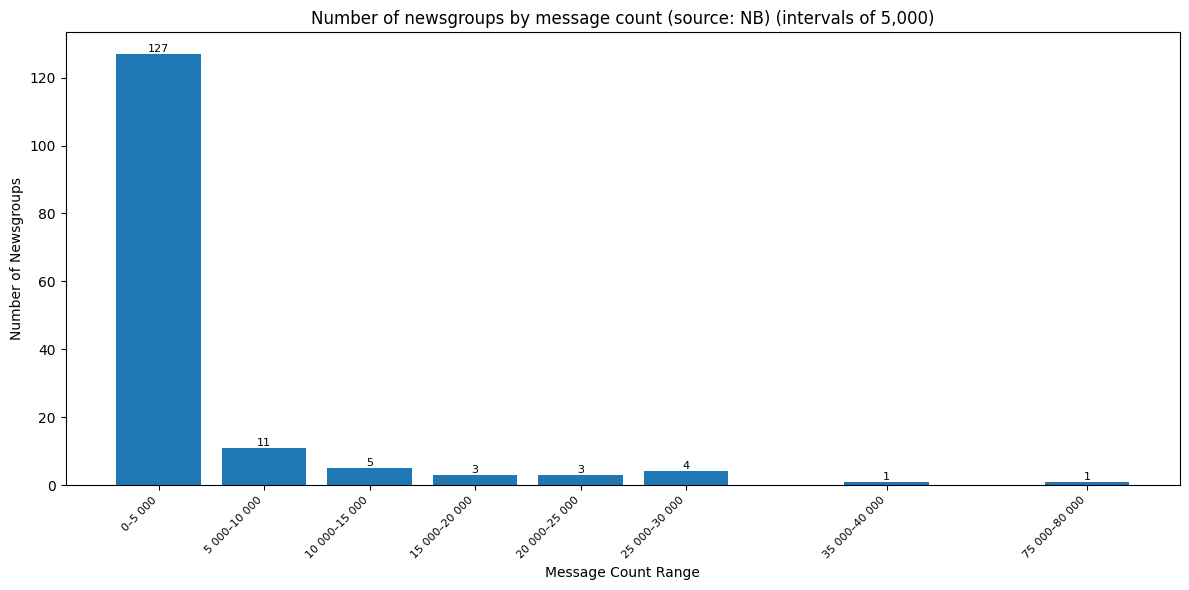

In [22]:
plot_distribution(
    df_nb,
    "Number of newsgroups by message count (source: NB) (intervals of 5,000)",
)